# Perform unfolding on EEG data from Stop-signal task with RidgeCV - one regularization for the whole model

In [1]:
import pickle
import warnings
import os
import mne
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from himalaya.ridge import RidgeCV

# sys.path.insert(1, '../')
from simple_ridgeCV_model import UnfoldSimpleRidgeCVModelPy
import simple_ridgeCV_model
from models import models
import unfold_utils

os.environ["OMP_NUM_THREADS"] = "4"
os.environ["MKL_NUM_THREADS"] = "4"
# Suppress FutureWarning
warnings.simplefilter(action='ignore', category=FutureWarning)

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


  Activating project at `~/Projects/neuroNoodle/unfold`


Status `~/Projects/neuroNoodle/unfold/Project.toml`
  [a93c6f00] DataFrames v1.7.0
⌃ [181c99d8] Unfold v0.7.6
  [ec0f67a1] UnfoldDecode v0.1.0 `https://github.com/unfoldtoolbox/UnfoldDecode.jl#main`
None
Info Packages marked with ⌃ have new versions available and may be upgradable.


   Resolving package versions...
  No Changes to `~/Projects/neuroNoodle/unfold/Project.toml`
  No Changes to `~/Projects/neuroNoodle/unfold/Manifest.toml`
Precompiling project...
  ✓ NNlib → NNlibForwardDiffExt
  ✓ MLUtils
  ✓ StatisticalMeasuresBase
  ✓ MLJEnsembles
  ✓ MLJBase
  ✓ StatisticalMeasures
  ✓ StatisticalMeasures → ScientificTypesExt
  ✓ MLJBase → DefaultMeasuresExt
  ✓ MLJFlow
  ✓ MLJBalancing
  ✓ MLJTuning
  ✓ MLJIteration
  ✓ MLJ
  ✓ UnfoldDecode
  14 dependencies successfully precompiled in 27 seconds. 216 already precompiled.
   Resolving package versions...
  No Changes to `~/Projects/neuroNoodle/unfold/Project.toml`
  No Changes to `~/Projects/neuroNoodle/unfold/Manifest.toml`
    Updating git-repo `https://github.com/unfoldtoolbox/UnfoldDecode.jl`
   Resolving package versions...
  No Changes to `~/Projects/neuroNoodle/unfold/Project.toml`
  No Changes to `~/Projects/neuroNoodle/unfold/Manifest.toml`
[ Info: Precompiling UnfoldDecode [ec0f67a1-ae9f-4687-b20b-bd39d

Status `~/Projects/neuroNoodle/unfold/Project.toml`
  [a93c6f00] DataFrames v1.7.0
⌃ [181c99d8] Unfold v0.7.6
  [ec0f67a1] UnfoldDecode v0.1.0 `https://github.com/unfoldtoolbox/UnfoldDecode.jl#main`
None
Info Packages marked with ⌃ have new versions available and may be upgradable.


Precompiling project...
  ✓ NNlib → NNlibFFTWExt
  1 dependency successfully precompiled in 5 seconds. 229 already precompiled.
   Resolving package versions...
  No Changes to `~/Projects/neuroNoodle/unfold/Project.toml`
  No Changes to `~/Projects/neuroNoodle/unfold/Manifest.toml`
    Updating git-repo `https://github.com/unfoldtoolbox/UnfoldDecode.jl`
   Resolving package versions...
  No Changes to `~/Projects/neuroNoodle/unfold/Project.toml`
  No Changes to `~/Projects/neuroNoodle/unfold/Manifest.toml`
  Activating project at `~/Projects/neuroNoodle/unfold`
   Resolving package versions...


Status `~/Projects/neuroNoodle/unfold/Project.toml`
  [a93c6f00] DataFrames v1.7.0
⌃ [181c99d8] Unfold v0.7.6
  [ec0f67a1] UnfoldDecode v0.1.0 `https://github.com/unfoldtoolbox/UnfoldDecode.jl#main`
None
Info Packages marked with ⌃ have new versions available and may be upgradable.


  No Changes to `~/Projects/neuroNoodle/unfold/Project.toml`
  No Changes to `~/Projects/neuroNoodle/unfold/Manifest.toml`
   Resolving package versions...
  No Changes to `~/Projects/neuroNoodle/unfold/Project.toml`
  No Changes to `~/Projects/neuroNoodle/unfold/Manifest.toml`
    Updating git-repo `https://github.com/unfoldtoolbox/UnfoldDecode.jl`
   Resolving package versions...
  No Changes to `~/Projects/neuroNoodle/unfold/Project.toml`
  No Changes to `~/Projects/neuroNoodle/unfold/Manifest.toml`


Define picks

In [2]:
picks = [
    'Fp1',
    'AF3',
    'F7',
    'F3',
    'FC1',
    'FC5',
    'T7',
    'C3',
    'CP1',
    'CP5',
    'P7',
    'P3',
    'Pz',
    'PO3',
    'O1',
    'Oz',
    'O2',
    'PO4',
    'P4',
    'P8',
    'CP6',
    'CP2',
    'C4',
    'T8',
    'FC6',
    'FC2',
    'F4',
    'F8',
    'AF4',
    'Fp2',
    'Fz',
    'Cz',
]

## Read events and EEG data

In [3]:
events_data_dir = '../data/output'
eeg_data_dir = '../data/Export SST N=54_Correct filtr 0.1-15 Hz'

pickle_events_files = sorted([f for f in os.listdir(events_data_dir) if f.endswith('.pickle')])
file_names = [os.path.splitext(f)[0] for f in pickle_events_files]

print(f'Found: {len(file_names)} pickle files')

Found: 54 pickle files


## Perform RidgeCV unfolding

In [4]:
current_unfold_model = models.get_full_model()

In [6]:
for file_name in file_names[:1]:
    # try:
        # read events dict
    with open(f'{events_data_dir}/{file_name}.pickle', 'rb') as handle:
        events = pickle.load(handle) # events dict channel_name:events_df

    # read EEG
    raw = mne.io.read_raw_brainvision(
        f'{eeg_data_dir}/{file_name}.vhdr',
        preload=True,
        eog=('HEOG', 'VEOG'),
    ).pick(picks=picks)

    # perform unfolding separately for each channel
    # channels = raw.info['ch_names']
    channels = ['Fz']
    results_channels = dict()
    for channel in channels:
        channel_events_df = events[channel]
        # clear bad segments
        channel_events_df = channel_events_df[channel_events_df['bad'] == False]
        # get EEG data
        eeg_data = raw.get_data(picks=channel)
        # cast EEG data from V to uV
        eeg_data = eeg_data * 1000000
        
        model = UnfoldSimpleRidgeCVModelPy(
            u_model = current_unfold_model,
            # linear_estimator = RidgeCV(alphas=np.logspace(-10, 10, num=21, base=10))
            linear_estimator=RidgeCV(alphas=[10**20])
        )
        model.fit(eeg_data, channel_events_df)

        results_channel_df = model.get_results(predicted=True, signal=eeg_data, events_df=channel_events_df)
        results_channels[channel] = results_channel_df

    # except Exception as e:
    #     print(e)

Extracting parameters from ../data/Export SST N=54_Correct filtr 0.1-15 Hz/AB0407_SST14_EOG4.vhdr...
Setting channel info structure...
Reading 0 ... 22769  =      0.000 ...   355.766 secs...


/var/folders/1_/b6g54cj10qj9pmtdn3v29ryc0000gn/T/ipykernel_14194/1677512571.py:8: RuntimeWarning: No coordinate information found for channels ['A1', 'A2']. Setting channel types to misc. To avoid this warning, set channel types explicitly.
  raw = mne.io.read_raw_brainvision(
/var/folders/1_/b6g54cj10qj9pmtdn3v29ryc0000gn/T/ipykernel_14194/1677512571.py:8: RuntimeWarning: Not setting positions of 4 eog/misc channels found in montage:
['HEOG', 'VEOG', 'A1', 'A2']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw = mne.io.read_raw_brainvision(
/Users/anuszka/Projects/neuroNoodle/unfold/unfold_model.py:604: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexin

In [7]:
res = results_channels['Fz']

-0.36319831621065785


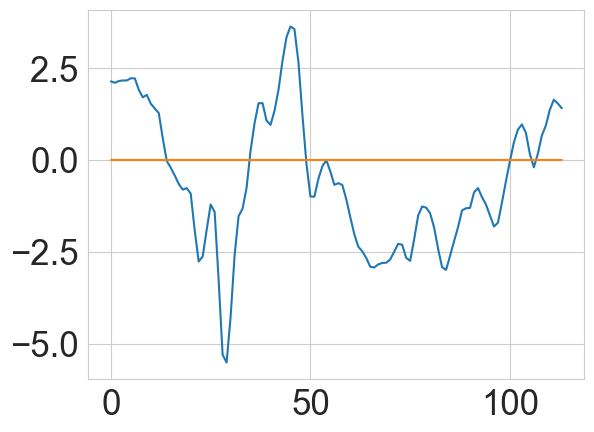

In [16]:
predicted_signal = res[res['coefname'] == 'predicted']['estimate'].to_numpy().flatten()
original_signal = res[res['coefname'] == 'original']['estimate'].to_numpy().flatten()

plt.plot(original_signal, label='original')
plt.plot(predicted_signal, label='predicted')

print(np.corrcoef(original_signal, predicted_signal)[0, 1])

In [17]:
model.coeftable['estimate'].to_numpy()

array([ 4.34934929e-16,  4.28133872e-16,  4.14022105e-16,  4.05005850e-16,
        4.00982447e-16,  3.97320498e-16,  3.91828001e-16,  3.81587139e-16,
        3.71636278e-16,  3.67986504e-16,  3.62991133e-16,  3.55415164e-16,
        3.51646236e-16,  3.45010671e-16,  3.38963854e-16,  3.28557300e-16,
        3.16057217e-16,  3.11071219e-16,  3.03776091e-16,  3.02327703e-16,
        3.09264932e-16,  3.04269616e-16,  2.86751797e-16,  2.71063077e-16,
        2.56686144e-16,  2.46088133e-16,  2.41404645e-16,  2.42308878e-16,
        2.47670325e-16,  2.47738992e-16,  2.47674793e-16,  2.50115832e-16,
        2.49820835e-16,  2.49343160e-16,  2.48203448e-16,  2.45844640e-16,
        2.47033482e-16,  2.42406756e-16,  2.31712032e-16,  2.29533977e-16,
        2.33154254e-16,  2.34874359e-16,  2.29635633e-16,  2.25673413e-16,
        2.29532654e-16,  2.31904955e-16,  2.29134323e-16,  2.18511242e-16,
        2.01441901e-16,  1.92551673e-16,  1.99851233e-16,  2.20794734e-16,
        2.32218596e-16,  

### Simple visualization

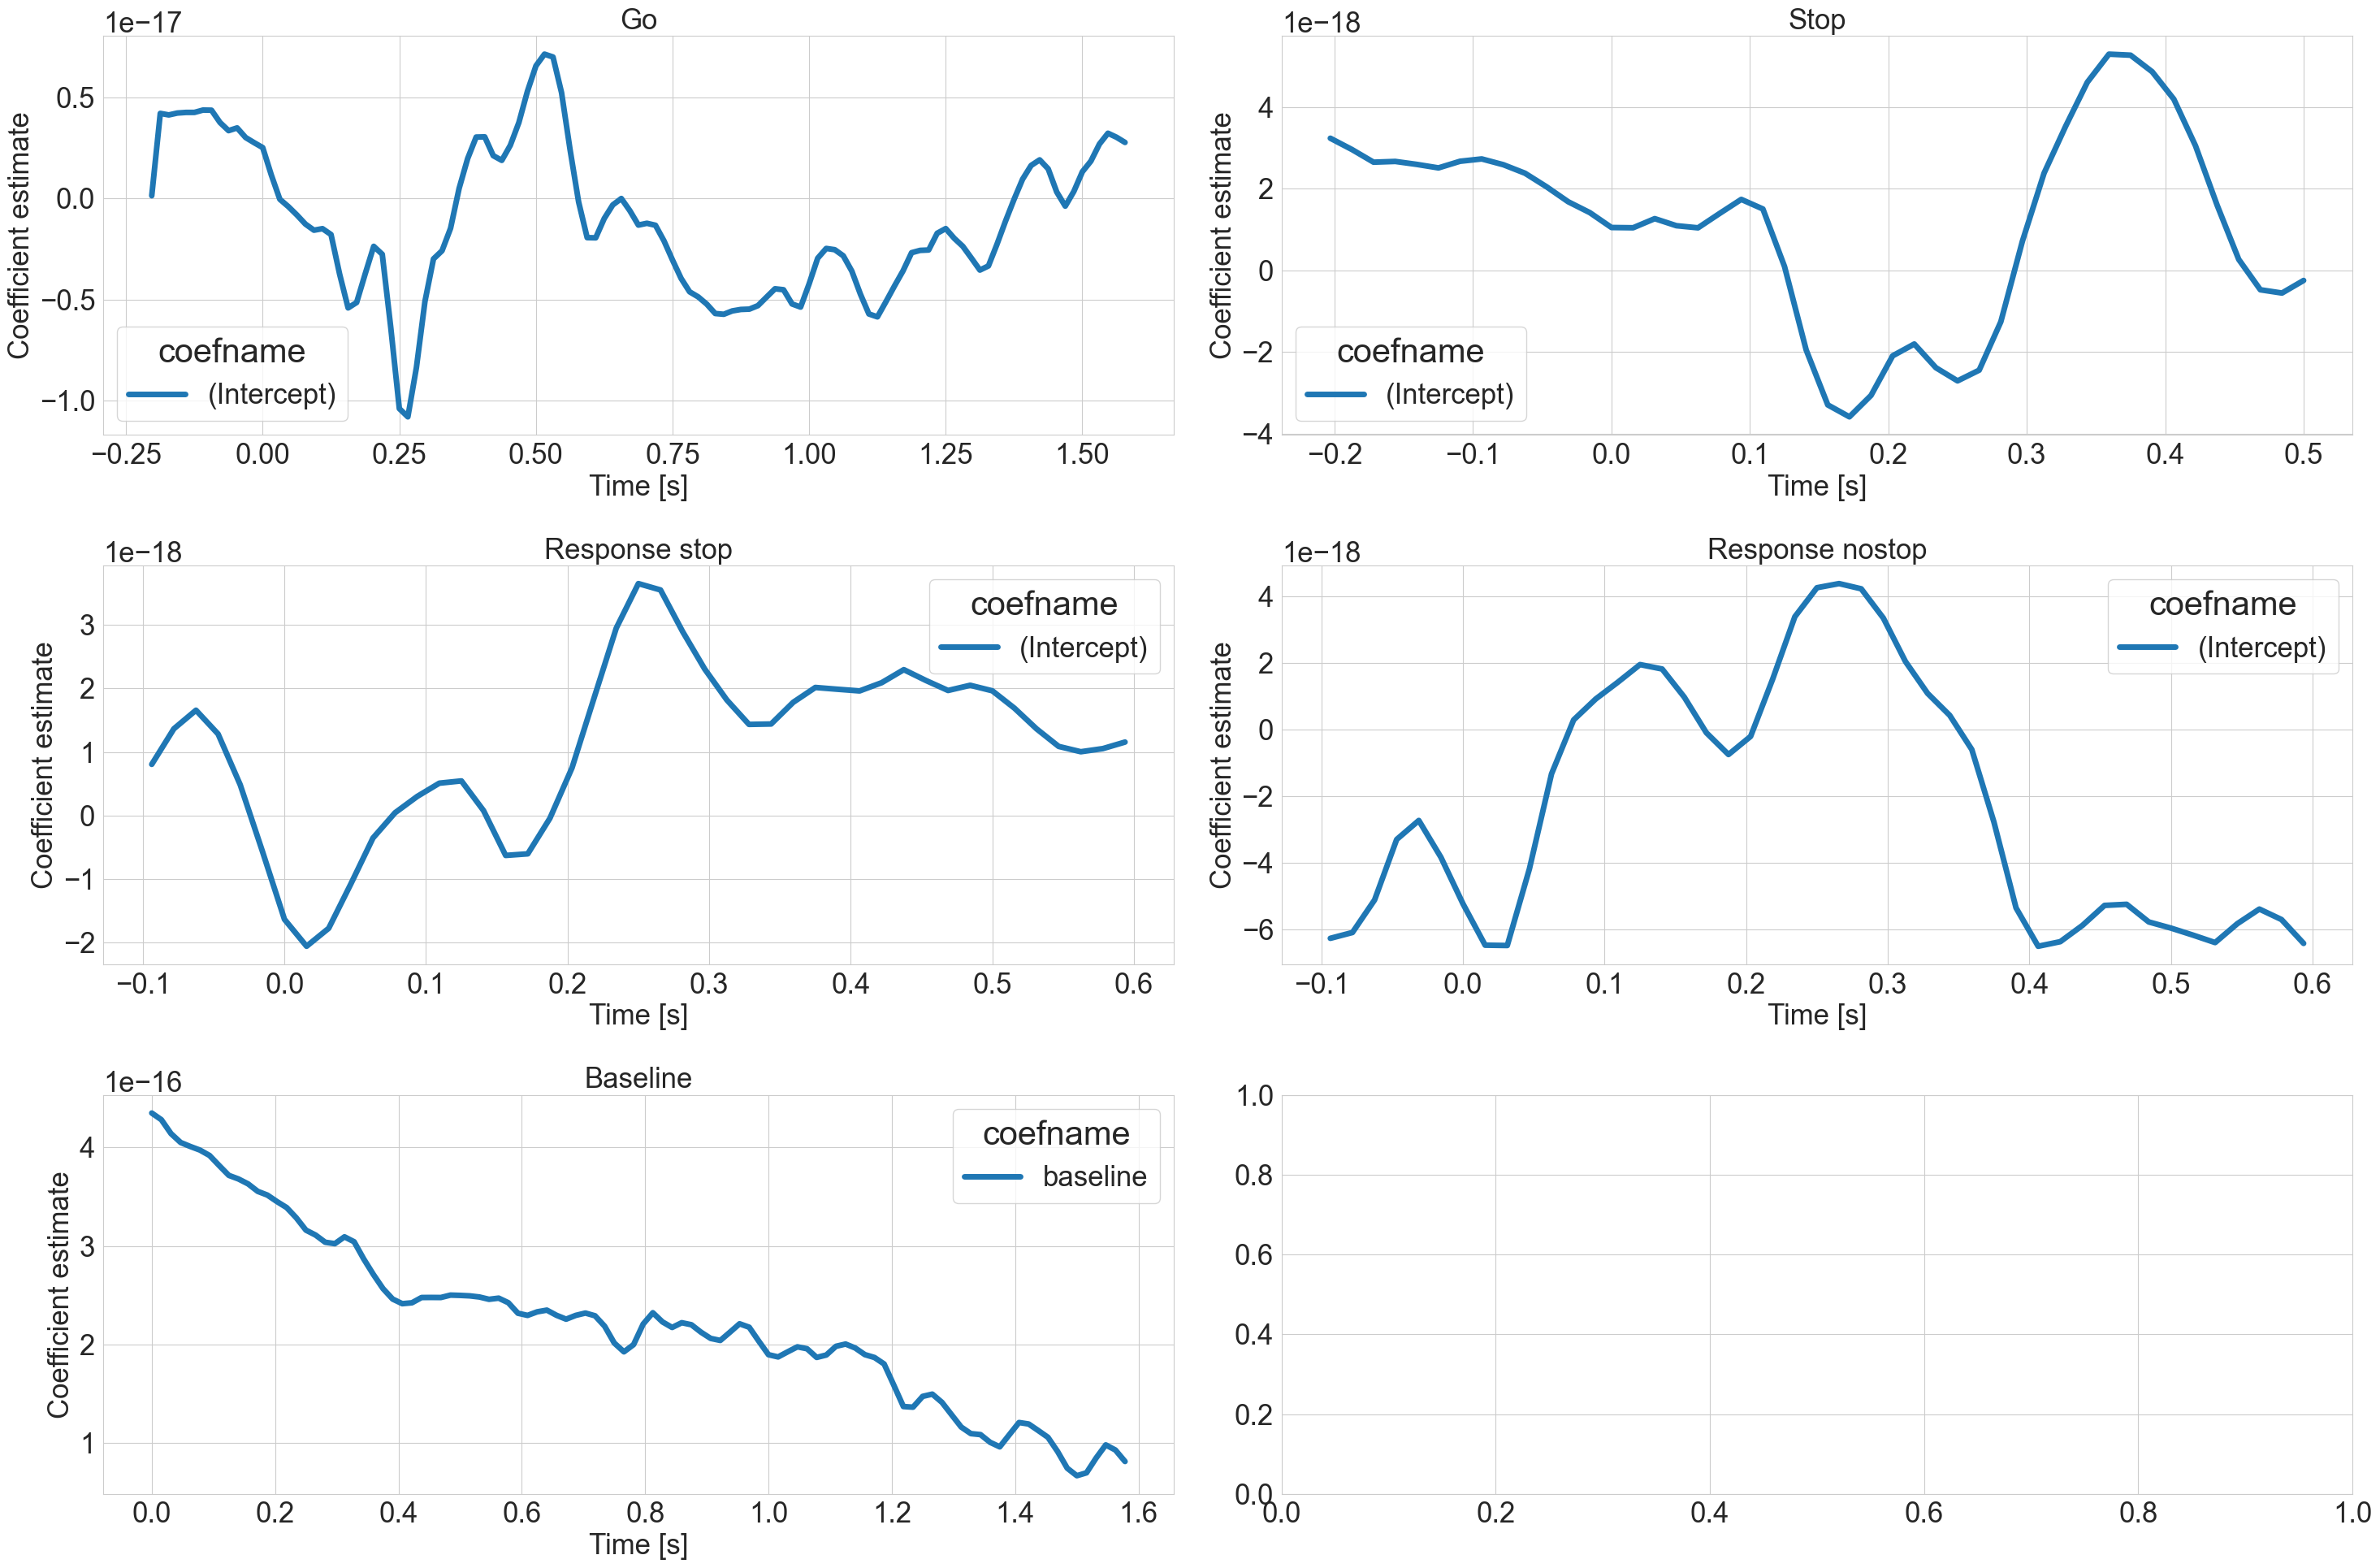

In [18]:
coef_table = model.coeftable
unfold_utils.plot_unfold_results_effects(coef_table)

In [14]:
rr = results_channels['Fz']
pred_sig = rr[rr['coefname'] == 'predicted']['estimate'].to_numpy()
org = rr[rr['coefname'] == 'original']['estimate'].to_numpy()
pred_sig.shape

(114,)

In [15]:
pred_raw_train = simple_ridgeCV_model.evoked_from_raw(predicted_raw_train, channel_events_df)
pred_raw_train.shape

NameError: name 'predicted_raw_train' is not defined

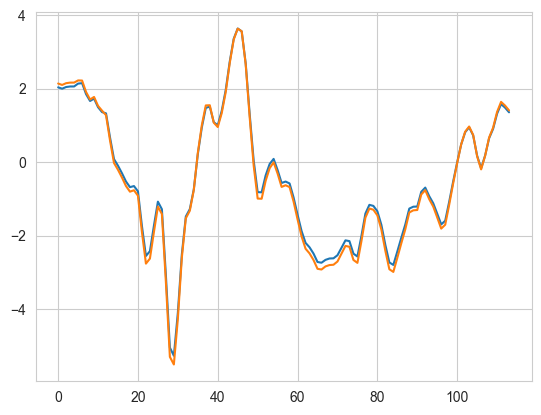

In [16]:
plt.plot(pred_sig)
plt.plot(org)

In [14]:
predicted_raw_train.shape

(1, 22769)

In [29]:
np.logspace(-10, 10, num=100, base=10)

array([1.00000000e-10, 1.59228279e-10, 2.53536449e-10, 4.03701726e-10,
       6.42807312e-10, 1.02353102e-09, 1.62975083e-09, 2.59502421e-09,
       4.13201240e-09, 6.57933225e-09, 1.04761575e-08, 1.66810054e-08,
       2.65608778e-08, 4.22924287e-08, 6.73415066e-08, 1.07226722e-07,
       1.70735265e-07, 2.71858824e-07, 4.32876128e-07, 6.89261210e-07,
       1.09749877e-06, 1.74752840e-06, 2.78255940e-06, 4.43062146e-06,
       7.05480231e-06, 1.12332403e-05, 1.78864953e-05, 2.84803587e-05,
       4.53487851e-05, 7.22080902e-05, 1.14975700e-04, 1.83073828e-04,
       2.91505306e-04, 4.64158883e-04, 7.39072203e-04, 1.17681195e-03,
       1.87381742e-03, 2.98364724e-03, 4.75081016e-03, 7.56463328e-03,
       1.20450354e-02, 1.91791026e-02, 3.05385551e-02, 4.86260158e-02,
       7.74263683e-02, 1.23284674e-01, 1.96304065e-01, 3.12571585e-01,
       4.97702356e-01, 7.92482898e-01, 1.26185688e+00, 2.00923300e+00,
       3.19926714e+00, 5.09413801e+00, 8.11130831e+00, 1.29154967e+01,
      